In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("../src")
)

from data.dataset import load_all_clients

datasets = load_all_clients(
    "../data/raw"
)

print(datasets.keys())

dict_keys(['DT1', 'DT2', 'DT3'])


## 슬롯별 사용 차량 수 

In [7]:
def plot_slot_vehicle_count(
    timeline,
    client_id
):

    slot_df = (
        timeline
        .dropna(subset=["park_slot_id"])
        .groupby("park_slot_id")["car_id"]
        .nunique()
        .sort_index()
    )

    ax = slot_df.plot(
        kind="bar",
        figsize=(12,5)
    )

    ax.set_title(
        f"{client_id} - Vehicle Count by Slot"
    )

    ax.set_xlabel("Slot ID")
    ax.set_ylabel("Vehicle Count")

    plt.show()

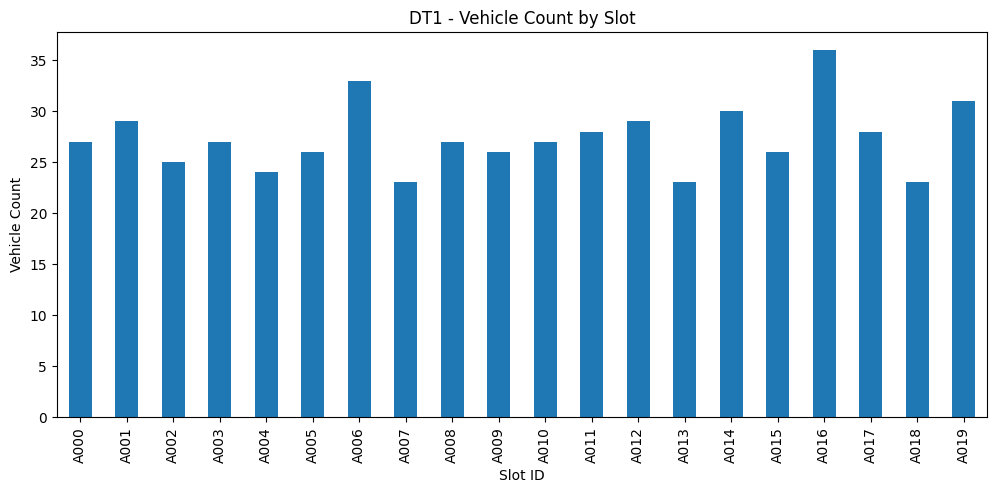

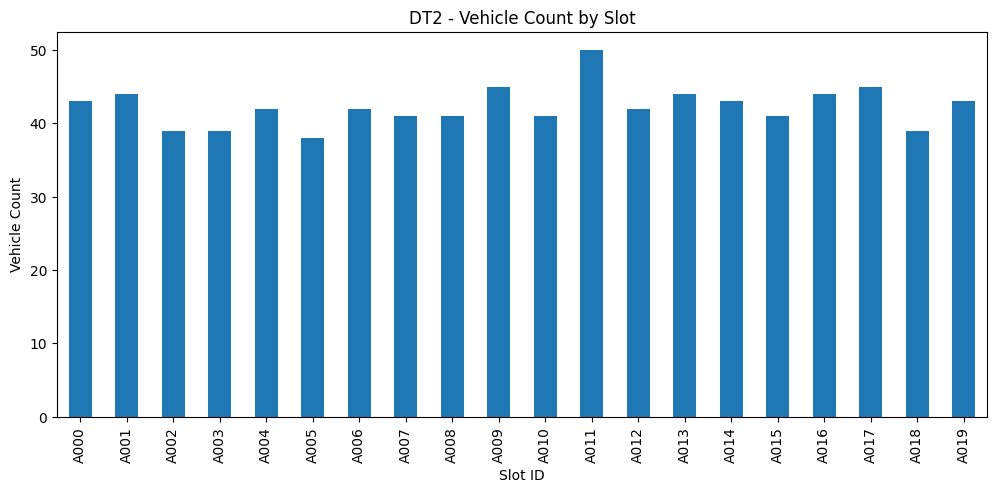

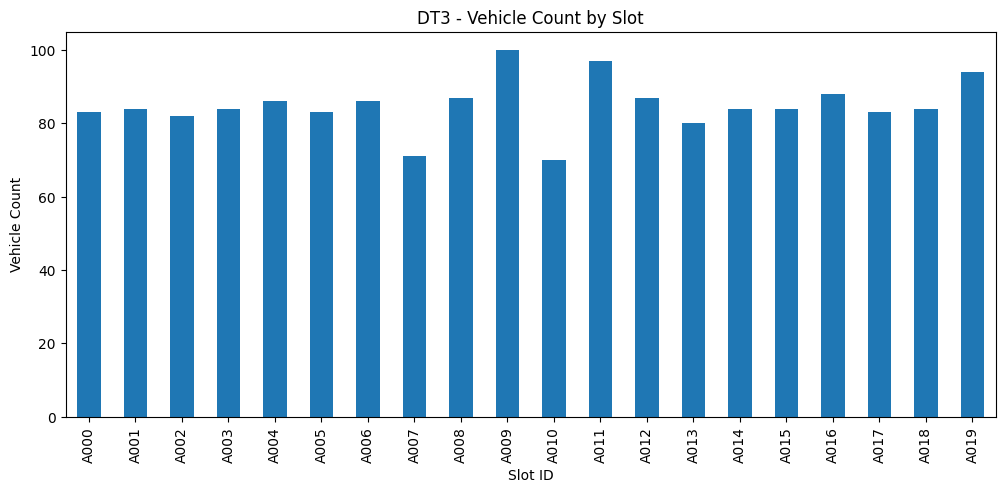

In [10]:
import matplotlib.pyplot as plt

for client_id in datasets.keys():
    plot_slot_vehicle_count(datasets[client_id]["timeline"], client_id)

## 체류시간 분포 비교(히스토그램)

In [19]:
import matplotlib.pyplot as plt


def plot_duration_hist_all(datasets):

    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(18, 5)
    )

    if len(datasets) == 1:
        axes = [axes]

    for ax, (client_id, data) in zip(
        axes,
        datasets.items()
    ):

        final = data["final"]

        ax.hist(
            final["duration"],
            bins=30
        )

        ax.set_title(
            f"{client_id} Duration Distribution"
        )

        ax.set_xlabel(
            "Duration (sec)"
        )

        ax.set_ylabel(
            "Count"
        )

        ax.grid(True)

    plt.tight_layout()

    plt.show()

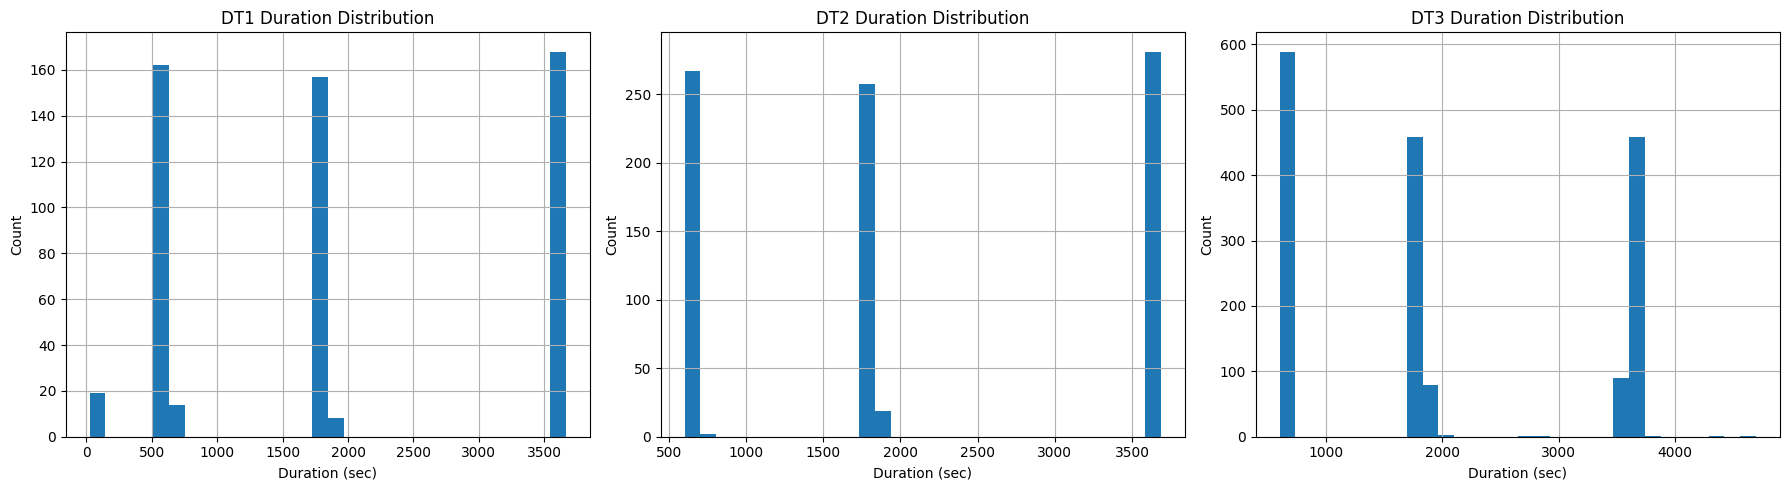

In [20]:
plot_duration_hist_all(datasets)

## 체류시간 빈도수 막대그래프

In [21]:
import matplotlib.pyplot as plt


def plot_duration_count_all(
    datasets,
    top_n=20
):

    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(18, 5)
    )

    if len(datasets) == 1:
        axes = [axes]

    for ax, (client_id, data) in zip(
        axes,
        datasets.items()
    ):

        final = data["final"]

        duration_count = (

            final["duration"]
            .value_counts()
            .sort_index()
            .head(top_n)
        )

        duration_count.plot(
            kind="bar",
            ax=ax
        )

        ax.set_title(
            f"{client_id} Duration Count"
        )

        ax.set_xlabel(
            "Duration (sec)"
        )

        ax.set_ylabel(
            "Vehicle Count"
        )

    plt.tight_layout()

    plt.show()

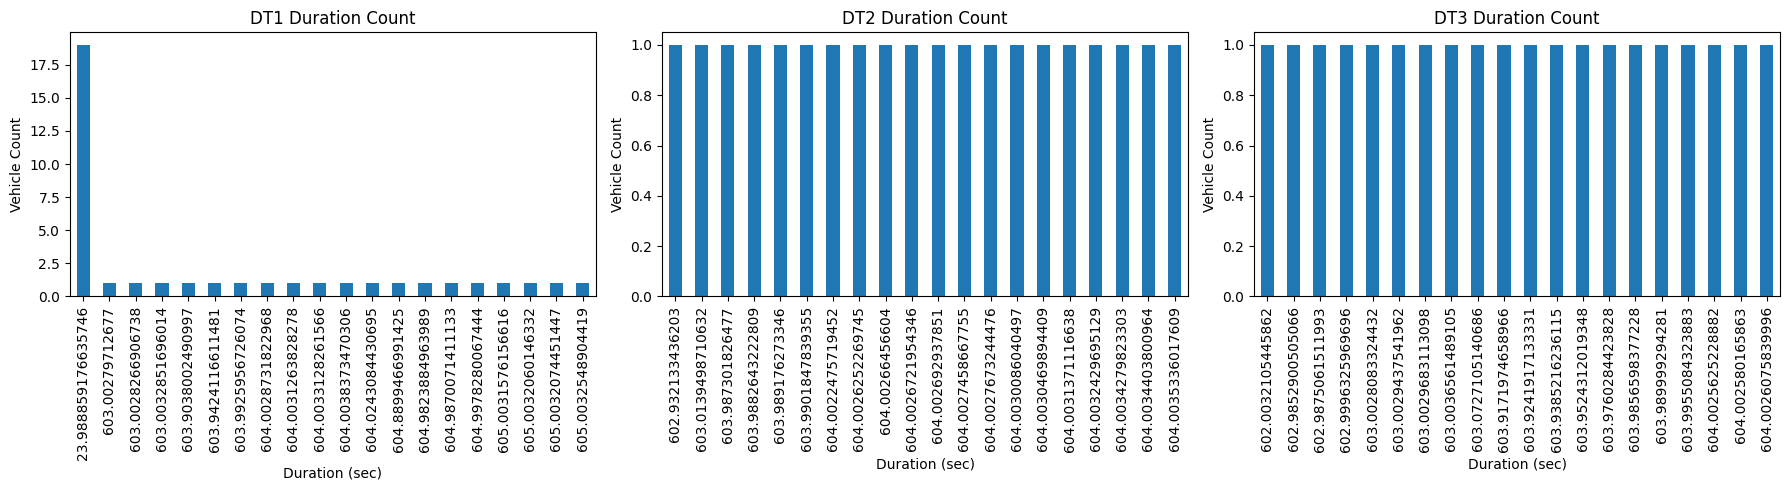

In [22]:
plot_duration_count_all(datasets)

In [23]:
for client_id, data in datasets.items():

    final = data["final"]

    print("=" * 50)
    print(client_id)

    print(
        final["duration"]
        .describe()
    )

    print(
        "\nUnique Duration:",
        final["duration"].nunique()
    )

    print(
        "\nTop 10 Duration"
    )

    print(
        final["duration"]
        .value_counts()
        .head(10)
    )

    print()

DT1
count     528.000000
mean     1923.594634
std      1271.797890
min        23.988859
25%       615.742020
50%      1808.994003
75%      3606.018226
max      3668.019280
Name: duration, dtype: float64

Unique Duration: 510

Top 10 Duration
duration
23.988859      19
3608.018911     1
605.999203      1
3612.023395     1
3619.014449     1
3622.003557     1
1806.036821     1
3612.019618     1
1811.031513     1
1807.009922     1
Name: count, dtype: int64

DT2
count     826.000000
mean     2037.496551
std      1234.097249
min       602.932133
25%       621.003347
50%      1812.008305
75%      3606.980888
max      3689.016195
Name: duration, dtype: float64

Unique Duration: 826

Top 10 Duration
duration
3623.101353    1
1837.007984    1
3606.017905    1
3617.017591    1
617.002660     1
3614.024654    1
1804.051054    1
610.053524     1
1812.025037    1
3607.010788    1
Name: count, dtype: int64

DT3
count    1683.000000
mean     1989.975353
std      1242.651538
min       602.003211
25%   

In [ ]:
def plot_slot_log_count(timeline):

    (
        timeline["park_slot_id"]
        .dropna()
        .value_counts()
        .sort_index()
        .plot(
            kind="bar",
            figsize=(12,5),
            title=f"Occupancy Log Count by Slot"
        )
    )
    plt.show()

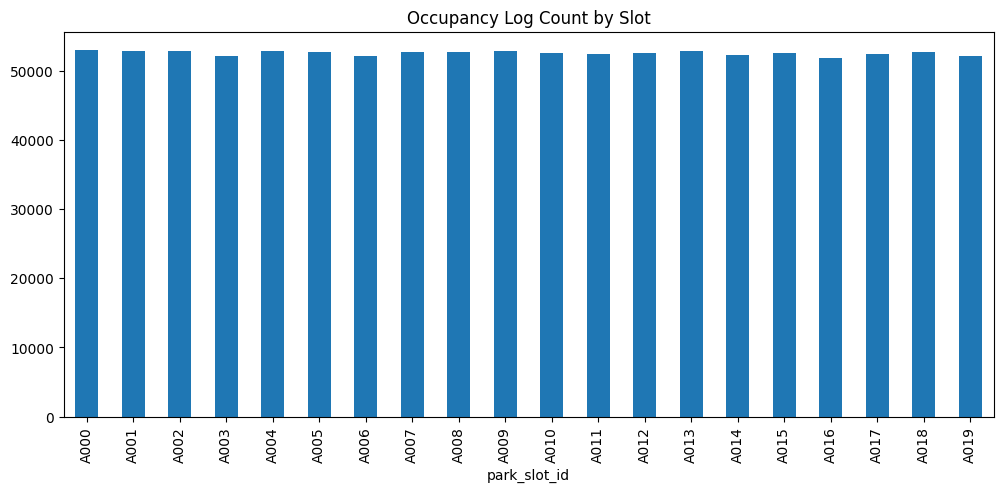

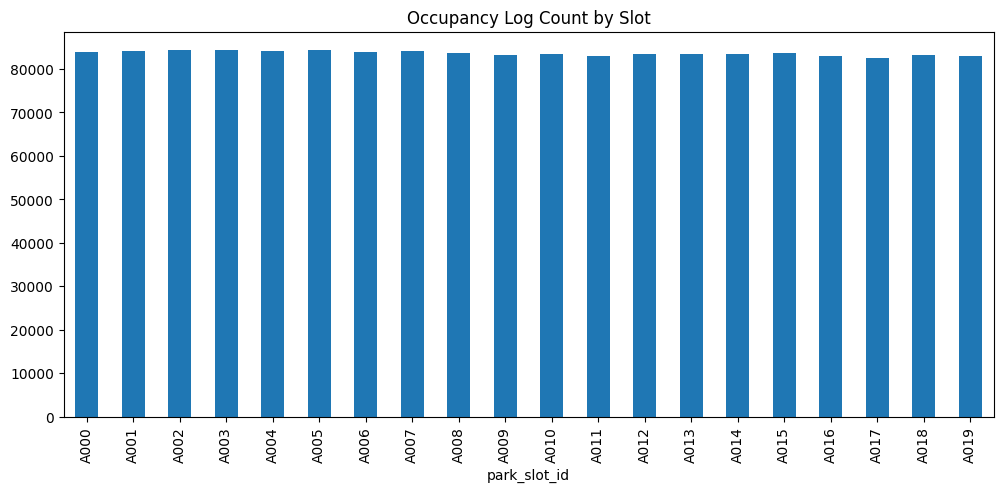

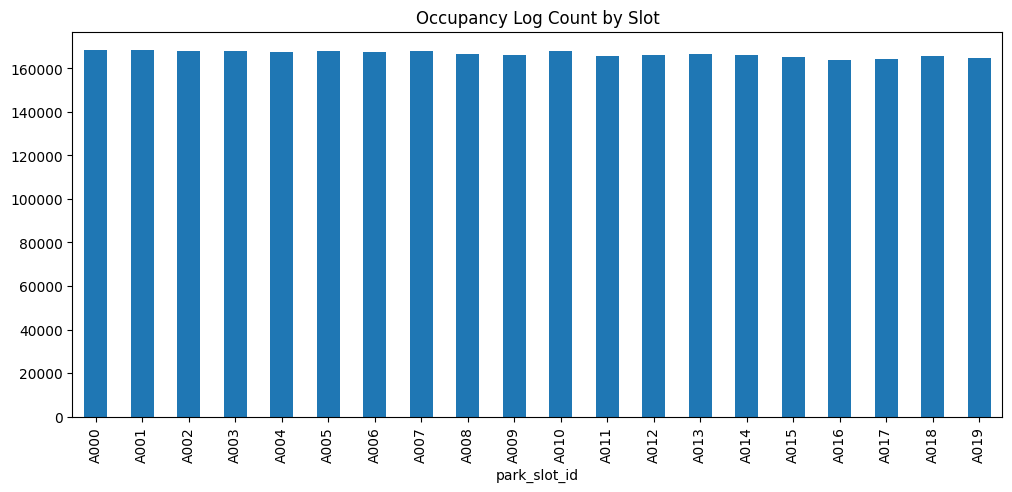

In [12]:
for client_id in datasets.keys():
    plot_slot_log_count(datasets[client_id]["timeline"])

In [13]:
def plot_duration_hist(final):

    final["duration"].hist(
        bins=30,
        figsize=(10,5)
    )

    plt.show()

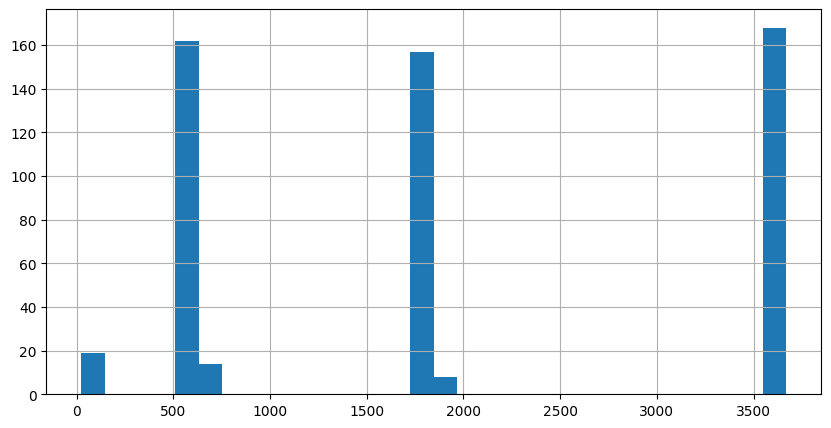

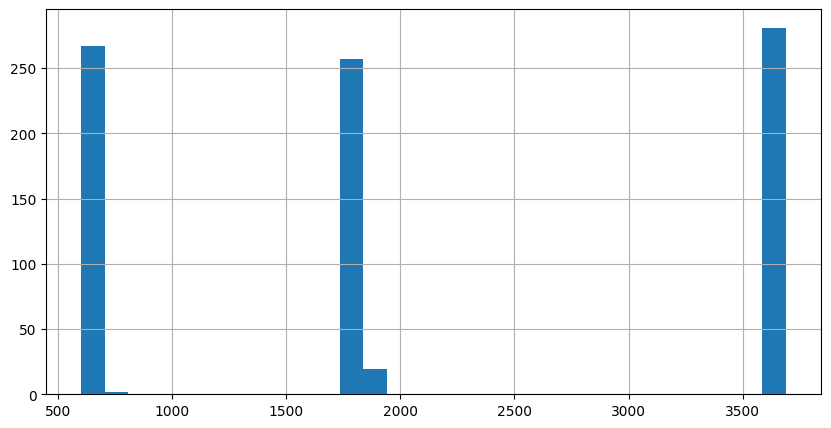

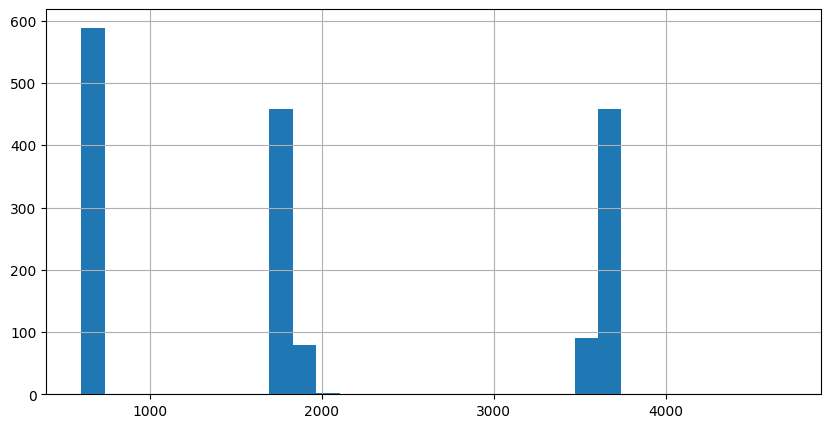

In [15]:
for client_id in datasets:

    plot_duration_hist(
        datasets[client_id]["final"]
    )

In [16]:
final = datasets["DT1"]["final"]

print(final["duration"].describe())

print("\n고유값 개수")
print(final["duration"].nunique())

print("\n상위 20개")
print(
    final["duration"]
    .value_counts()
    .head(20)
)

count     528.000000
mean     1923.594634
std      1271.797890
min        23.988859
25%       615.742020
50%      1808.994003
75%      3606.018226
max      3668.019280
Name: duration, dtype: float64

고유값 개수
510

상위 20개
duration
23.988859      19
3608.018911     1
605.999203      1
3612.023395     1
3619.014449     1
3622.003557     1
1806.036821     1
3612.019618     1
1811.031513     1
1807.009922     1
1808.010127     1
1816.009882     1
1805.009821     1
3606.018150     1
3622.017720     1
3606.019062     1
3604.037158     1
609.000952      1
3605.027958     1
3605.018866     1
Name: count, dtype: int64


In [17]:
print(
    sorted(
        final["duration"].unique()
    )[:50]
)

[23.988859176635746, 603.00279712677, 603.0028266906738, 603.0032851696014, 603.9038002490997, 603.9424116611481, 603.9925956726074, 604.0028731822968, 604.0031263828278, 604.0033128261566, 604.0038373470306, 604.0243084430695, 604.8899466991425, 604.9823884963989, 604.9870071411133, 604.9978280067444, 605.0031576156616, 605.0032060146332, 605.0032074451447, 605.0032548904419, 605.0032713413239, 605.0032773017883, 605.0034246444702, 605.003847360611, 605.0038638114929, 605.0120277404785, 605.0136256217957, 605.0139660835266, 605.021124124527, 605.0299646854401, 605.0528926849365, 605.0813708305359, 605.9905745983124, 605.990716457367, 605.9992029666901, 606.0027296543121, 606.0029466152191, 606.0029683113098, 606.0032336711884, 606.0032386779785, 606.0033633708954, 606.0035197734833, 606.003645658493, 606.0122804641724, 606.0184161663055, 606.0499532222748, 606.9249045848846, 606.9554846286774, 606.9703001976013, 606.9958884716034]


## 슬롯별 이용 차량 수

In [27]:
import pandas as pd

def slot_vehicle_compare_table(datasets):

    rows = []

    for client_id, data in datasets.items():

        timeline = data["timeline"]

        slot_vehicle = (

            timeline
            .dropna(
                subset=["park_slot_id"]
            )

            .groupby(
                "park_slot_id"
            )["car_id"]

            .nunique()

            .sort_index()
        )

        row = {
            "client": client_id
        }

        for slot, count in slot_vehicle.items():
            row[slot] = count

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("client")
    )

In [28]:
slot_vehicle_compare_table(datasets)

,A000,A001,A002,A003,A004,A005,A006,A007,A008,A009,A010,A011,A012,A013,A014,A015,A016,A017,A018,A019
client,,,,,,,,,,,,,,,,,,,,
DT1,27,29,25,27,24,26,33,23,27,26,27,28,29,23,30,26,36,28,23,31
DT2,43,44,39,39,42,38,42,41,41,45,41,50,42,44,43,41,44,45,39,43
DT3,83,84,82,84,86,83,86,71,87,100,70,97,87,80,84,84,88,83,84,94


In [38]:
def compare_duration_bins(datasets):

    bins = [
        0,
        600,
        1200,
        1800,
        2400,
        3000,
        3600,
        5000
    ]

    labels = [
        "0~10m",
        "10~20m",
        "20~30m",
        "30~40m",
        "40~50m",
        "50~60m",
        "60m+"
    ]

    rows = []

    for client_id, data in datasets.items():

        final = data["final"]

        duration_group = pd.cut(
            final["duration"],
            bins=bins,
            labels=labels
        )

        counts = (
            duration_group
            .value_counts()
            .sort_index()
        )

        row = {
            "client": client_id
        }

        for label in labels:
            row[label] = counts.get(
                label,
                0
            )

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("client")
    )

In [39]:
duration_bin_df = compare_duration_bins(
    datasets
)

display(duration_bin_df)

,0~10m,10~20m,20~30m,30~40m,40~50m,50~60m,60m+
client,,,,,,,
DT1,19,176,0,165,0,0,168
DT2,0,269,0,276,0,0,281
DT3,0,589,0,540,2,0,552
